# FairPCA

Fair PCA with CKA penalty (100 epochs).

In [1]:
from __future__ import annotations

import os

os.environ["KERAS_BACKEND"] = "jax"

import matplotlib.pyplot as plt
import numpy as np

from fairkl.models import FairPCA
from fairkl.metrics.cka import cka_rbf
from _style import SCATTER_KW, style_ax

## Synthetic Data

4D: dims 0-1 shifted by binary group, dims 2-3 noise.

In [2]:
rng = np.random.default_rng(0)
n = 300
q_raw = rng.choice([-1.0, 1.0], size=n).astype("float32")
q = q_raw.reshape(-1, 1)
group_a = q_raw > 0

X = np.column_stack(
    [
        3.0 * q_raw + rng.standard_normal(n) * 0.5,
        2.0 * q_raw + rng.standard_normal(n) * 0.5,
        rng.standard_normal(n) * 1.5,
        rng.standard_normal(n) * 1.0,
    ]
).astype("float32")

print(f"n={n}, d={X.shape[1]}, A={group_a.sum()}, B={(~group_a).sum()}")

n=300, d=4, A=163, B=137


## Standard vs Fair PCA

In [3]:
pca_std = FairPCA(n_components=2, mu=0.0)
pca_std.fit(X, epochs=100, lr=0.02)
Z_std = np.array(pca_std.transform(X))
V_unfair = np.array(pca_std._V.value)  # save for warm-starting

# Warm-start the fair model from the unfair solution
pca_fair = FairPCA(n_components=2, mu=500.0, sigma_q=0.5)
pca_fair.fit(X, q=q, epochs=1, lr=0.02)  # build
pca_fair._V.assign(V_unfair)
pca_fair.fit(X, q=q, epochs=100, lr=0.02)
Z_fair = np.array(pca_fair.transform(X))

CKA — standard: 0.6757,  fair: 0.4612


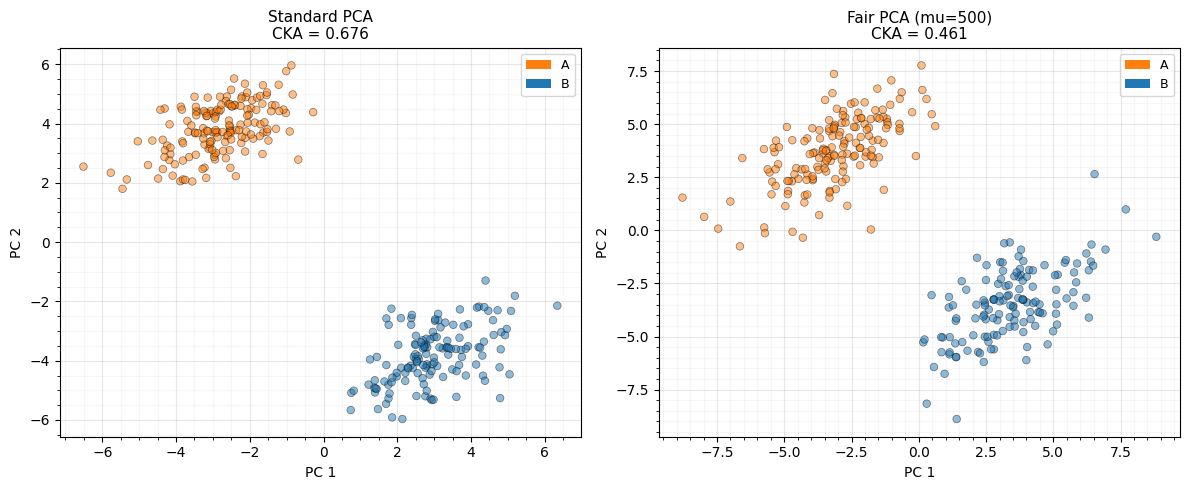

In [4]:
cka_std = float(cka_rbf(Z_std.astype("float32"), q))
cka_fair = float(cka_rbf(Z_fair.astype("float32"), q))
print(f"CKA — standard: {cka_std:.4f},  fair: {cka_fair:.4f}")

colors = np.where(group_a, "C1", "C0")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(Z_std[:, 0], Z_std[:, 1], c=colors, **SCATTER_KW)
axes[0].set_title(f"Standard PCA\nCKA = {cka_std:.3f}", fontsize=11)
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")
style_ax(axes[0])

axes[1].scatter(Z_fair[:, 0], Z_fair[:, 1], c=colors, **SCATTER_KW)
axes[1].set_title(f"Fair PCA (mu=500)\nCKA = {cka_fair:.3f}", fontsize=11)
axes[1].set_xlabel("PC 1")
axes[1].set_ylabel("PC 2")
style_ax(axes[1])

from matplotlib.patches import Patch

for ax in axes:
    ax.legend(
        handles=[Patch(facecolor="C1", label="A"), Patch(facecolor="C0", label="B")],
        fontsize=9,
    )
plt.tight_layout()
plt.show()

## Histograms of PC 1

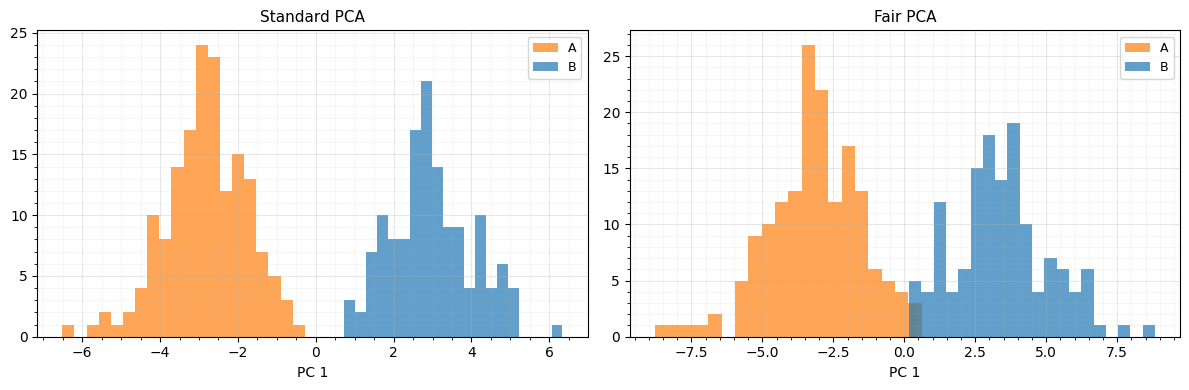

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, Z, title in zip(axes, [Z_std, Z_fair], ["Standard PCA", "Fair PCA"]):
    ax.hist(Z[group_a, 0], bins=20, alpha=0.7, color="C1", label="A")
    ax.hist(Z[~group_a, 0], bins=20, alpha=0.7, color="C0", label="B")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("PC 1")
    ax.legend(fontsize=9)
    style_ax(ax)
plt.tight_layout()
plt.show()

## Fairness Sweep

mu=    0  recon=0.490  CKA=0.676


mu=   10  recon=0.487  CKA=0.619


mu=   50  recon=0.582  CKA=0.591


mu=  100  recon=0.704  CKA=0.568


mu=  500  recon=1.544  CKA=0.461


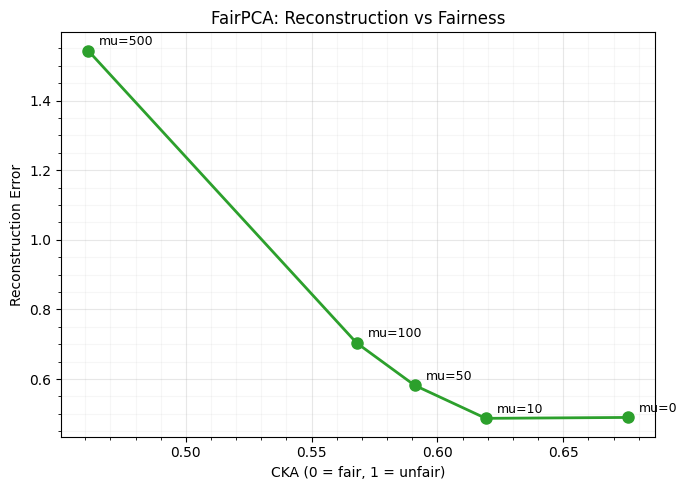

In [6]:
# Use the standard PCA solution (mu=0) as the warm-start for all
# fairness-penalized runs, so the optimizer traces a consistent path.

mus = [0, 10, 50, 100, 500]
recon_list, cka_list = [], []

for mu in mus:
    if mu == 0:
        m = pca_std  # reuse the already-trained standard PCA
    else:
        m = FairPCA(n_components=2, mu=mu, sigma_q=0.5)
        m.fit(X, q=q, epochs=1, lr=0.02)  # build
        m._V.assign(V_unfair)  # warm-start from unfair solution
        m.fit(X, q=q, epochs=100, lr=0.02)
    Z = np.array(m.transform(X))
    recon = float(np.array(m.reconstruction_error(X)))
    c = float(cka_rbf(Z.astype("float32"), q))
    recon_list.append(recon)
    cka_list.append(c)
    print(f"mu={mu:5d}  recon={recon:.3f}  CKA={c:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(cka_list, recon_list, "o-", color="C2", lw=2, markersize=8)
for i, mu in enumerate(mus):
    ax.annotate(
        f"mu={mu}",
        (cka_list[i], recon_list[i]),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=9,
    )
ax.set_xlabel("CKA (0 = fair, 1 = unfair)")
ax.set_ylabel("Reconstruction Error")
ax.set_title("FairPCA: Reconstruction vs Fairness")
style_ax(ax)
plt.tight_layout()
plt.show()